## Imports et chargement des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Chargement du dataset
df = pd.read_csv("../data/raw/predictive_maintenance.csv")

print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Dimensions du dataset : 10000 lignes, 10 colonnes


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


## Vérification qualité des données

In [3]:
print("=== Valeurs manquantes ===")
print(df.isnull().sum())

print("\n=== Doublons ===")
print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")

print("\n=== Types de colonnes ===")
print(df.dtypes)

=== Valeurs manquantes ===
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

=== Doublons ===
Nombre de lignes dupliquées : 0

=== Types de colonnes ===
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                   str
dtype: object


##  Répartition des pannes (graphique 1)

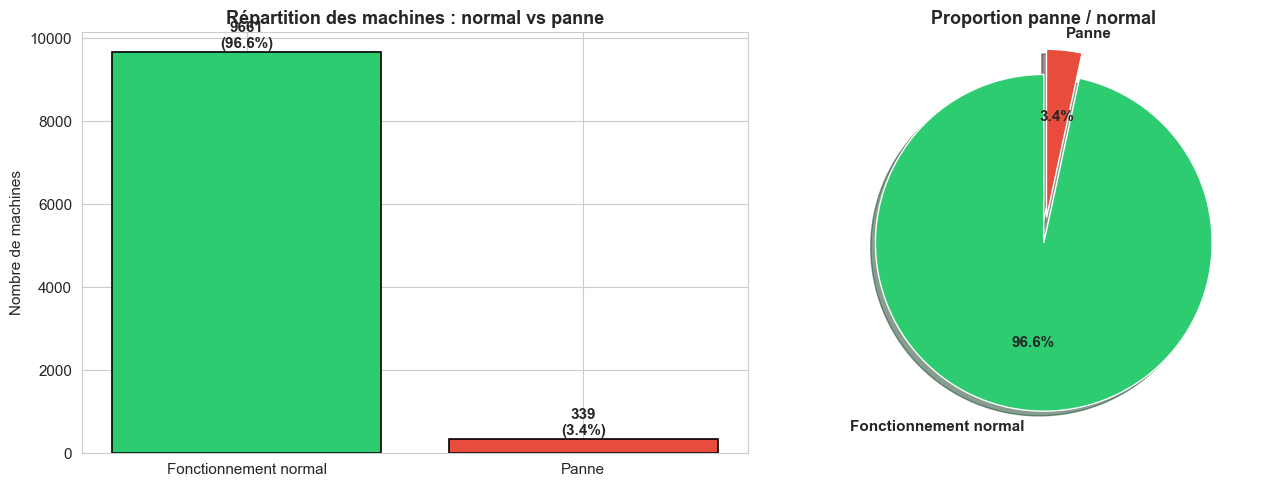

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique en barres : nombre de machines par statut ---
couleurs = ['#2ecc71', '#e74c3c']  # vert = OK, rouge = panne
counts = df['Target'].value_counts().sort_index()
labels = ['Fonctionnement normal', 'Panne']

axes[0].bar(labels, counts.values, color=couleurs, edgecolor='black', linewidth=1.2)
axes[0].set_title("Répartition des machines : normal vs panne", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Nombre de machines")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')

# --- Camembert : même info en proportion ---
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=couleurs,
            startangle=90, explode=(0, 0.15), shadow=True,
            textprops={'fontweight': 'bold'})
axes[1].set_title("Proportion panne / normal", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("../docs/repartition_pannes.png", dpi=150, bbox_inches='tight')
plt.show()

 ## Types de pannes en détail

C:\Users\imane\AppData\Local\Temp\ipykernel_35232\29573555.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=failure_counts.values, y=failure_counts.index, palette=palette, edgecolor='black')


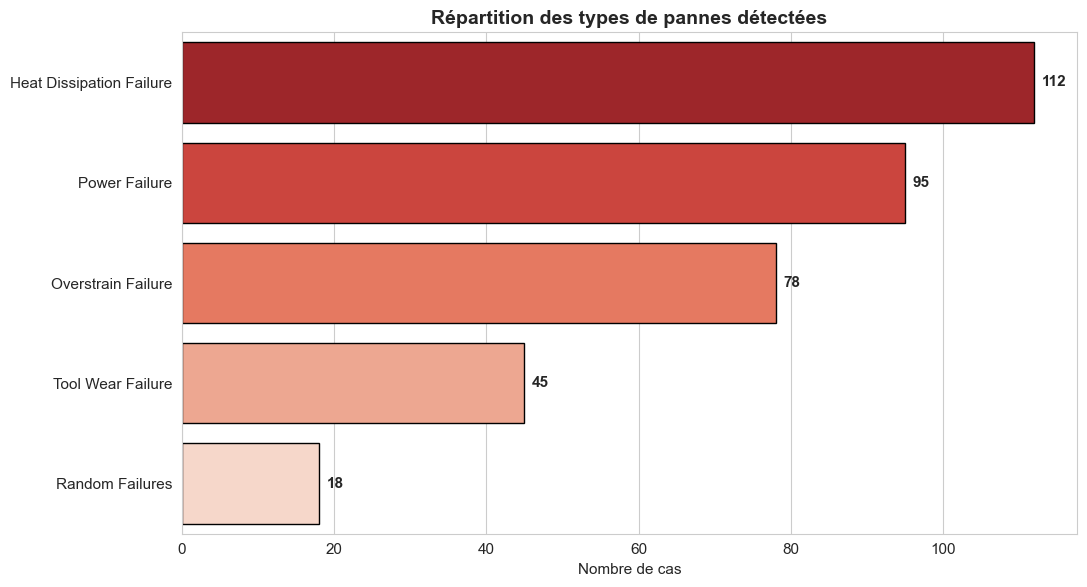

In [6]:
plt.figure(figsize=(11, 6))

failure_counts = df[df['Failure Type'] != 'No Failure']['Failure Type'].value_counts()

palette = sns.color_palette("Reds_r", len(failure_counts))
ax = sns.barplot(x=failure_counts.values, y=failure_counts.index, palette=palette, edgecolor='black')

plt.title("Répartition des types de pannes détectées", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de cas")
plt.ylabel("")

# Ajouter les valeurs sur les barres
for i, v in enumerate(failure_counts.values):
    ax.text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../docs/types_pannes.png", dpi=150, bbox_inches='tight')
plt.show()

## Distribution des capteurs (température, vitesse, couple, usure)

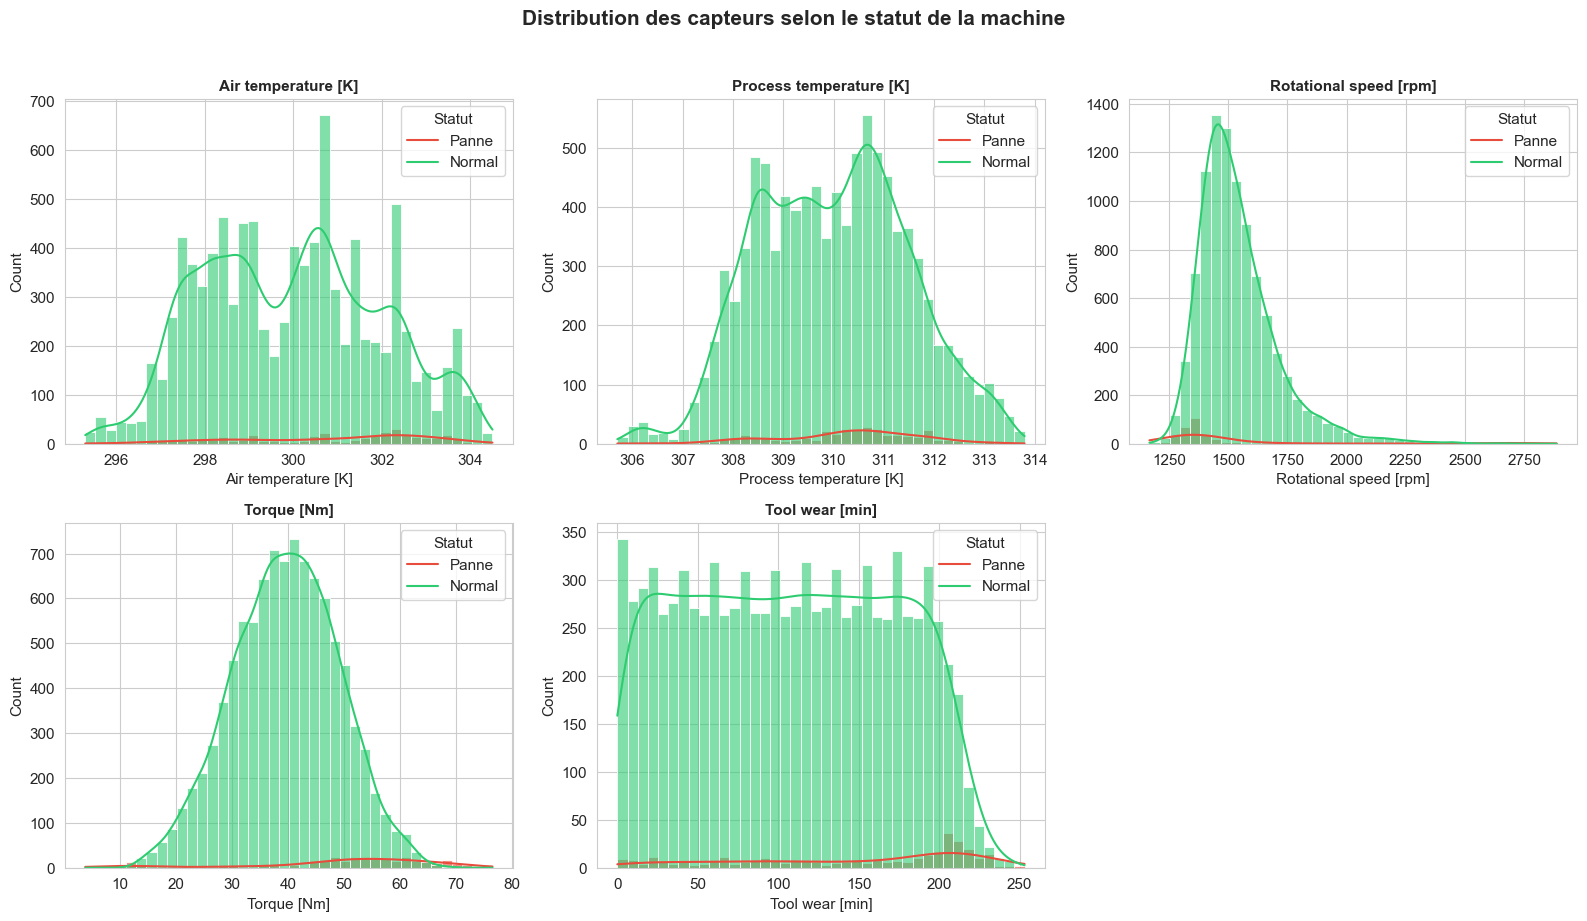

In [7]:
capteurs = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(capteurs):
    sns.histplot(data=df, x=col, hue='Target', kde=True, ax=axes[i],
                 palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.6, bins=40)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(labels=['Panne', 'Normal'], title='Statut')

axes[5].axis('off')  # on cache la 6e case vide

plt.suptitle("Distribution des capteurs selon le statut de la machine", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../docs/distribution_capteurs.png", dpi=150, bbox_inches='tight')
plt.show()

## Matrice de corrélation

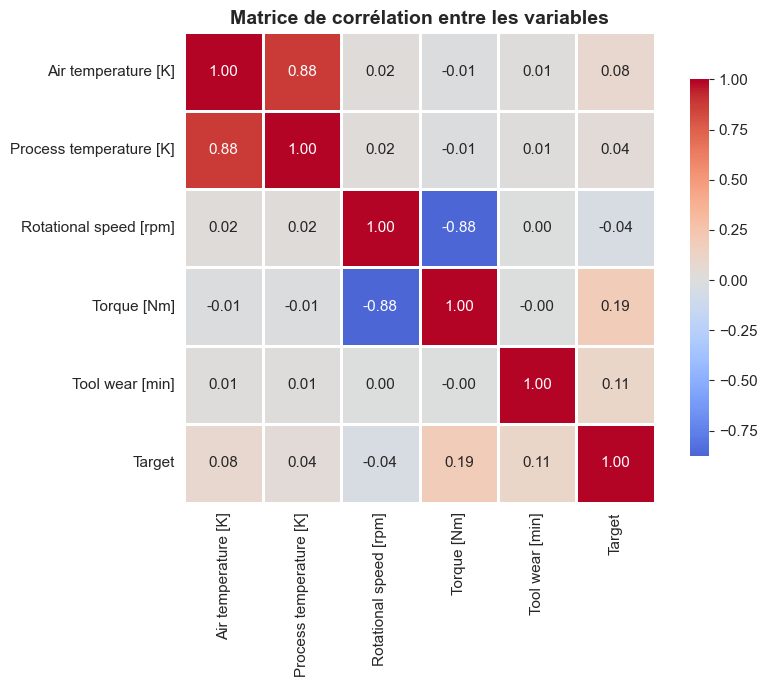

In [8]:
plt.figure(figsize=(9, 7))

colonnes_numeriques = ['Air temperature [K]', 'Process temperature [K]', 
                        'Rotational speed [rpm]', 'Torque [Nm]', 
                        'Tool wear [min]', 'Target']

correlation = df[colonnes_numeriques].corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title("Matrice de corrélation entre les variables", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../docs/correlation.png", dpi=150, bbox_inches='tight')
plt.show()

## Répartition par type de produit (L / M / H)

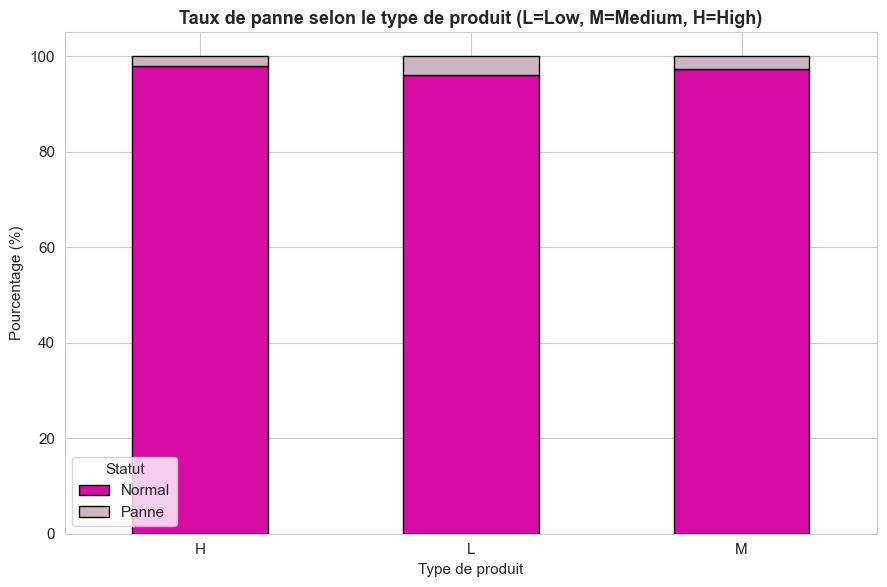

In [12]:
plt.figure(figsize=(9, 6))

ct = pd.crosstab(df['Type'], df['Target'], normalize='index') * 100

ct.plot(kind='bar', stacked=True, color=["#D70CA4", "#cfb4c6"], 
        edgecolor='black', ax=plt.gca())

plt.title("Taux de panne selon le type de produit (L=Low, M=Medium, H=High)", 
          fontsize=13, fontweight='bold')
plt.ylabel("Pourcentage (%)")
plt.xlabel("Type de produit")
plt.legend(['Normal', 'Panne'], title='Statut')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../docs/type_produit.png", dpi=150, bbox_inches='tight')
plt.show()